In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import scipy
import numpy as np

# Assortativity of groups through shared messages

In [ ]:
network = pd.read_csv("path/to/file/with/message/spreading/network.csv", compression = 'gzip')
no_consp = pd.read_csv("/path/to/file/with/groups/with/zero/conspiracy.csv")

In [ ]:
network['posting_date'] = pd.to_datetime(network['posting_date'], utc=True)
network['posting_date_spreaded'] = pd.to_datetime(network['posting_date_spreaded'], utc=True)

In [ ]:
#filter out non-conspiracy groups from message spreading network
no_consp_set = set(no_consp.iloc[:, 0])

orig_is_non   = network['group_name_orig'].isin(no_consp_set)
spread_is_non = network['group_name_spreaded'].isin(no_consp_set)
no_consp_mask = orig_is_non | spread_is_non

# rows to remove (any side non-conspiracy)
no_consp_messages = network.loc[no_consp_mask].copy()

# directional subsets
consp_to_non_consp_messages = network.loc[(~orig_is_non) & spread_is_non].copy()
non_consp_to_consp_messages = network.loc[orig_is_non & (~spread_is_non)].copy()

# keep only conspiracy↔conspiracy
network = network.loc[~no_consp_mask].copy()

Assortativity Matrix (correlation coefficients):

Source degree → Target degree:
            In                 Out
         r      p          r      p
---------------------------------------------
in    0.590 1.3e-45  -0.905 1.2e-176  
out  -0.790 3.6e-119  -0.106 1.2e-02  


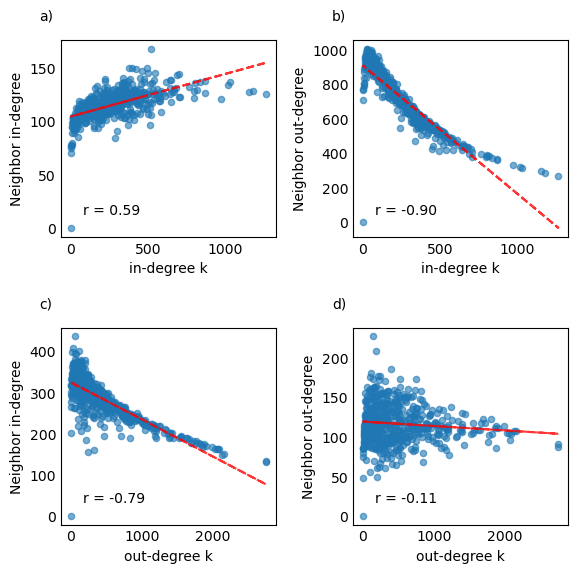

In [ ]:
def calculate_degree_assortativity_matrix(G):
    """
    Calculate assortativity for all combinations of in-degree and out-degree.
    Returns a 2x2 matrix of correlations.
    
    Parameters:
    -----------
    G : networkx.DiGraph
        Directed graph to analyze
    
    Returns:
    --------
    matrix : dict
        2x2 dictionary of correlation coefficients and p-values
    plots : dict
        Dictionary containing plot data for each combination
    """
    
    
    degree_types = ['in', 'out']
    
    
    matrix = {}
    plots = {}
    
    #calculate assortativity for all combinations of in-degree and out-degree neighbors
    for source in degree_types:
        matrix[source] = {}
        plots[source] = {}
        
        for target in degree_types:
            # Get degree connectivity
            knn_dict = nx.average_degree_connectivity(G, source=source, target=target)
            k, knn = list(knn_dict.keys()), list(knn_dict.values())
            
            #calculate correlation
            r, p_value = scipy.stats.pearsonr(k, knn)
            
            
            matrix[source][target] = {'r': r, 'p': p_value}
            plots[source][target] = {'k': k, 'knn': knn}
            
    return matrix, plots

edge_weights = (network.groupby(['group_name_orig', 'group_name_spreaded'])
                .size()
                .reset_index(name='weight'))

#create weighted graph
G = nx.DiGraph()
for _, row in edge_weights.iterrows():
    G.add_edge(row['group_name_orig'], 
               row['group_name_spreaded'], 
               weight=row['weight'])



#calculate assortativity matrix
assort_matrix, plot_data = calculate_degree_assortativity_matrix(G)

#print results in a readable format
print("Assortativity Matrix (correlation coefficients):")
print("\nSource degree → Target degree:")
print("            In                 Out")
print("         r      p          r      p")
print("-" * 45)
for source in ['in', 'out']:
    print(f"{source:4}", end=" ")
    for target in ['in', 'out']:
        r = assort_matrix[source][target]['r']
        p = assort_matrix[source][target]['p']
        print(f"{r:6.3f} {p:6.1e}  ", end="")
    print()

#create visualization of all combinations
fig, axes = plt.subplots(2, 2, figsize=(15/2.54, 15/2.54))
plt.style.use(plt.style.available[3])

#mark subplots
axes[0,0].text(-0.1, 1.1, 'a)', transform=axes[0,0].transAxes, fontsize=10)
axes[0,1].text(-0.1, 1.1, 'b)', transform=axes[0,1].transAxes, fontsize=10)
axes[1,0].text(-0.1, 1.1, 'c)', transform=axes[1,0].transAxes, fontsize=10)
axes[1,1].text(-0.1, 1.1, 'd)', transform=axes[1,1].transAxes, fontsize=10)


for i, source in enumerate(['in', 'out']):
    for j, target in enumerate(['in', 'out']):
        ax = axes[i, j]
        
        k = plot_data[source][target]['k']
        knn = plot_data[source][target]['knn']
        r = assort_matrix[source][target]['r']
        p = assort_matrix[source][target]['p']
        
        #scatter plot
        ax.scatter(k, knn, alpha=0.6, s=20)
        
        #correlation line
        z = np.polyfit(k, knn, 1)
        p_fit = np.poly1d(z)
        ax.plot(k, p_fit(k), "r--", alpha=0.8)
        
        #ax.set_xscale('log')
        #ax.set_yscale('log')
        ax.set_xlabel(f'{source}-degree k')
        ax.set_ylabel(f'Neighbor {target}-degree')
        
        #add correlation info
        ax.text(0.1, 0.1, f'r = {r:.2f}', 
                transform=ax.transAxes, 
                fontsize=10,
                verticalalignment='bottom',
                horizontalalignment= 'left')

plt.tight_layout()

#plt.savefig("path/to/destination/assortativity_matrix.pdf")


# Power Law distribution for the number authors per chat


In [1]:
import powerlaw
import polars as pl

In [ ]:
data = pl.scan_csv("/path/to/file").collect()

In [ ]:
group_info = (
    data
    .group_by("group_name")
    .agg([
        pl.n_unique("author").alias("n_authors"),
        pl.len().alias("n_messages_total"),
        pl.col("message").is_not_null().sum().alias("n_text_messages"),
        pl.col("fwd_message").is_not_null().sum().alias("n_fwd_text_messages"),
        pl.col("media_file").is_not_null().sum().alias("n_media"),
        pl.col("fwd_media_file").is_not_null().sum().alias("n_fwd_media"),

        (pl.col("media_file_type") == "photo").sum().alias("photos"),
        (pl.col("media_file_type") == "video").sum().alias("videos"),
        (pl.col("media_file_type") == "voice message").sum().alias("voice messages"),
        (pl.col("fwd_media_file_type") == "photo").sum().alias("fwd_photos"),
        (pl.col("fwd_media_file_type") == "video").sum().alias("fwd_videos"),
        (pl.col("fwd_media_file_type") == "voice message").sum().alias("fwd_voice messages"),
    ])
    .with_columns([
        pl.when(pl.col("n_authors") > 2)
        .then(pl.lit("group"))
        .otherwise(pl.lit("channel"))
        .alias("is_group"),
        (pl.col("n_media") + pl.col("n_fwd_media")).alias("total_media"),
        (pl.col("photos") + pl.col("fwd_photos")).alias("total_photos"),
        (pl.col("videos") + pl.col("fwd_videos")).alias("total_videos"),
        (pl.col("voice messages") + pl.col("fwd_voice messages")).alias("total_voice_m"),
        ((pl.col("n_media") + pl.col("n_fwd_media")) / pl.col("n_messages_total").cast(pl.Float64)).alias("media_ratio"),
    ])
)

# build summary_df as you did
summary_df = group_info.select(
    pl.lit("total").alias("group_name"),
    pl.col("n_authors").sum().alias("n_authors"),
    pl.format(
        "{} channels, {} groups",
        pl.col("is_group").eq("channel").cast(pl.Int64).sum(),
        pl.col("is_group").eq("group").cast(pl.Int64).sum(),
    ).alias("is_group"),
    pl.col("n_messages_total").sum().alias("n_messages_total"),
    pl.col("n_text_messages").sum().alias("n_text_messages"),
    pl.col("n_fwd_text_messages").sum().alias("n_fwd_text_messages"),
    pl.col("n_media").sum().alias("n_media"),
    pl.col("n_fwd_media").sum().alias("n_fwd_media"),
    pl.col("photos").sum().alias("photos"),
    pl.col("videos").sum().alias("videos"),
    pl.col("voice messages").sum().alias("voice messages"),
    pl.col("fwd_photos").sum().alias("fwd_photos"),
    pl.col("fwd_videos").sum().alias("fwd_videos"),
    pl.col("fwd_voice messages").sum().alias("fwd_voice messages"),
    pl.col("total_media").sum().alias("total_media"),
    pl.col("total_photos").sum().alias("total_photos"),
    pl.col("total_videos").sum().alias("total_videos"),
    pl.col("total_voice_m").sum().alias("total_voice_m"),
    (pl.col("total_media").sum() / pl.col("n_messages_total").sum()).cast(pl.Float64).alias("media_ratio"),
)

# ensure identical column order (and optionally dtypes) before vstack
summary_df = summary_df.select(group_info.columns)

group_info = group_info.vstack(summary_df)

In [ ]:
#get number of authors per group
gi = group_info.filter(pl.col("group_name") != "total")
vals = gi["n_authors"].to_numpy()

unique_values, counts = np.unique(vals, return_counts=True)
data_valid = vals[vals > 0]

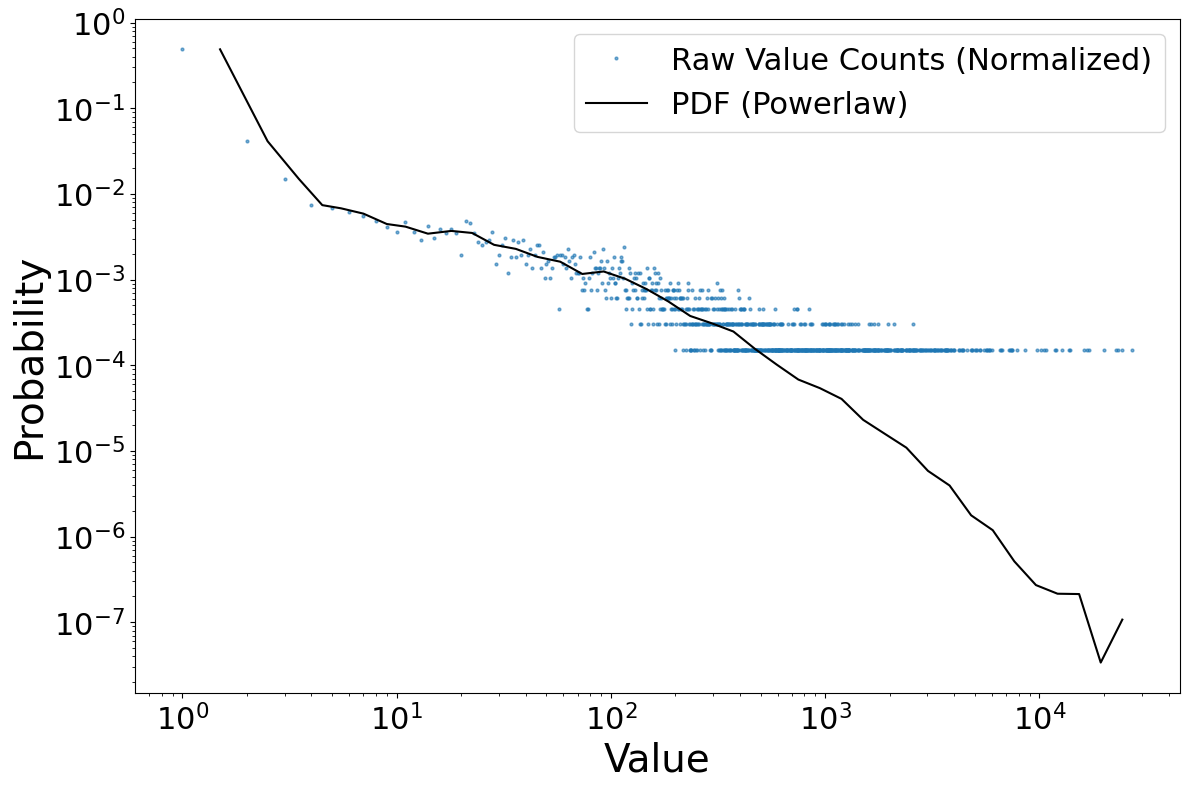

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

#normalize raw value counts to align with the PDF
normalized_counts = counts / np.sum(counts)  # Scale counts to probabilities

#plot raw value counts (normalized)
ax.loglog(unique_values, normalized_counts, 'o', label="Raw Value Counts (Normalized)", alpha=0.6, markersize=2)

#plot the PDF using powerlaw
powerlaw.plot_pdf(data_valid, ax=ax, linear_bins=False, label="PDF (Powerlaw)", color='k')

#ax.set_title("Log-Log Plot of PDF and Normalized Raw Value Counts", fontsize=14)
ax.set_xlabel("Value", fontsize=28)
ax.set_ylabel("Probability", fontsize=28)
ax.legend(fontsize=22)

#tick parameter
ax.tick_params(axis='both', which='major', labelsize=22)
ax.tick_params(axis='both', which='minor', labelsize=22)
#plt.grid(which="both", linestyle='--', linewidth=0.5)

fig.tight_layout()
#fig.savefig("path/to/destination/powerlaw_plot.pdf", format="pdf", bbox_inches="tight", dpi=300)


# Message and group activity timeline 


In [8]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from scipy.signal import find_peaks
from datetime import datetime

In [ ]:
data = data.to_pandas()

In [ ]:
# find peak dates in the posting frequency

#converge datatype
data['day'] = pd.to_datetime(data['posting_date'], errors='coerce', utc=True).dt.floor('D')

# messages per day
posting_frequency = data['day'].value_counts().sort_index()

# unique groups per day
groups_per_day = data.groupby('day')['group_name'].nunique().sort_index()

# unique authors per day
authors_per_day = data.groupby('day')['author'].nunique().sort_index()


ix = posting_frequency.index.union(groups_per_day.index).union(authors_per_day.index)
posting_frequency = posting_frequency.reindex(ix, fill_value=0)
groups_per_day    = groups_per_day.reindex(ix, fill_value=0)
authors_per_day   = authors_per_day.reindex(ix, fill_value=0)


#find local maxima
peaks, _ = find_peaks(posting_frequency.values, prominence=20000, distance = 40) #40 days between peaks to get separated events, tried multiple, this shows best interpretable results with explaining the visible spikes
peak_values = posting_frequency.values[peaks]
peak_dates = posting_frequency.index[peaks]

#get the 4 largest spikes
largest_spikes_idx = np.argsort(peak_values)[-1:]  #indices of 4 largest peaks
spike_dates = peak_dates[largest_spikes_idx]
spike_values = peak_values[largest_spikes_idx]

#spike values added manually
spike_values = np.append(spike_values, 165745)
spike_values = np.append(spike_values, 133919)
spike_values = np.append(spike_values, 48533)

In [ ]:
#spike dates added manually
spike_dates = spike_dates.append(pd.DatetimeIndex([datetime(2021, 1, 6, 12, 0, tzinfo=pd.Timestamp.now().tzinfo)]))
spike_dates = spike_dates.append(pd.DatetimeIndex([datetime(2020, 8, 29, 12, 0, tzinfo=pd.Timestamp.now().tzinfo)]))
spike_dates = spike_dates.append(pd.DatetimeIndex([datetime(2021, 12, 2, 12, 0, tzinfo=pd.Timestamp.now().tzinfo)]))


#spike descriptions added manually
spike_desc = []
spike_desc.append('(I) Inauguration Joe Biden')
spike_desc.append('(II) US Storm of the Capitol')
spike_desc.append('(III) Reichsbürger Demonstration \n at German Parliament')
spike_desc.append('(IV) Angela Merkel \n Grand Military Tattoo')

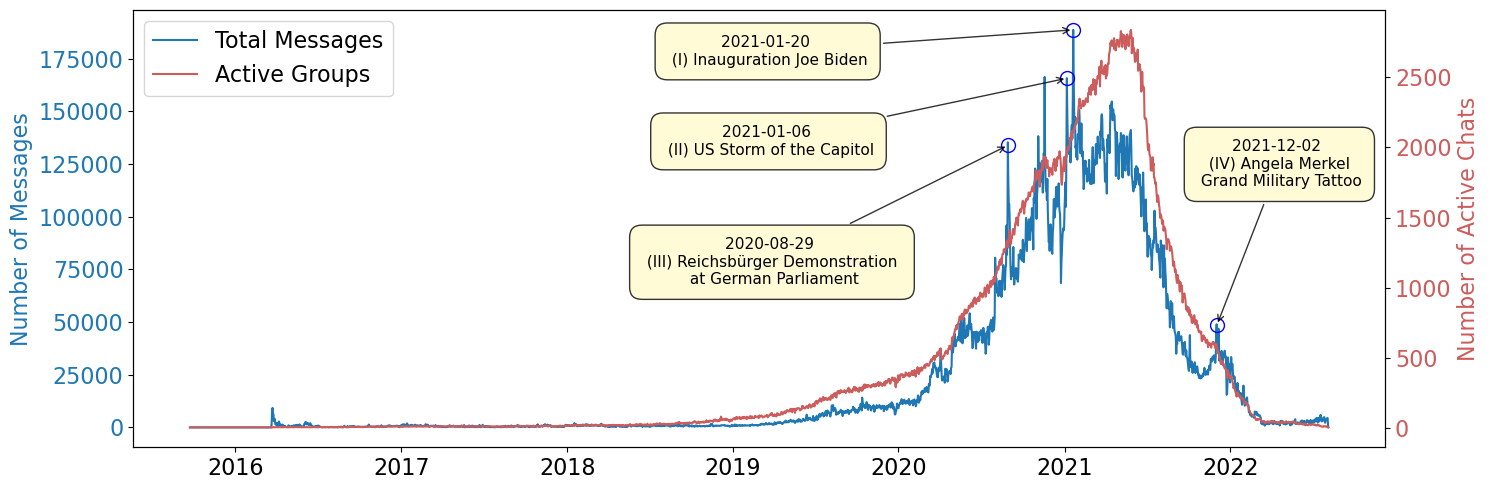

In [ ]:
fontsize = 16
text_color = 'black' 

#create figure with two y-axes
fig, ax1 = plt.subplots(figsize=(15, 5))
ax2 = ax1.twinx()

#plot1: total messages per day
ax1.plot(posting_frequency.index, posting_frequency, 'tab:blue', label='Total Messages')
ax1.set_ylabel('Number of Messages', color='tab:blue', fontsize=fontsize)
ax1.tick_params(axis='y', labelcolor='tab:blue', labelsize=fontsize)
ax1.tick_params(axis='x', labelcolor='black', labelsize=fontsize)

#plot2: number of active groups per day (active when at least one message was posted)
ax2.plot(groups_per_day.index, groups_per_day, 'indianred', label='Active Groups')
ax2.set_ylabel('Number of Active Chats', color='indianred', fontsize=fontsize)
ax2.tick_params(axis='y', labelcolor='indianred', labelsize=fontsize)

#annotate the spikes
offsets = [(-220, -25), (-215, -55), (-170, -100), (45, 100)]  # Different positions for annotations

for (date, value, text), (x_off, y_off) in zip(zip(spike_dates, spike_values, spike_desc), offsets):
    ax1.plot(date, value, 'bo', markersize=10, fillstyle='none')  # Circle
    ax1.annotate(f"{date.strftime('%Y-%m-%d')} \n {text}",
                xy=(date, value), 
                xytext=(x_off, y_off),
                textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.8', 
                         fc='lemonchiffon', 
                         alpha=0.8,
                         edgecolor=text_color),
                ha='center',
                color=text_color,
                fontsize=fontsize - 5,
                arrowprops=dict(arrowstyle='->',
                              color=text_color,
                              alpha=0.8))

#format x-axis to show only years
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

#add legend with increased fontsize
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, 
          loc='upper left',
          fontsize=fontsize)

plt.tight_layout()

#plt.savefig("path/to/destination/powerlaw_plot.pdf")
#plt.show()